# Proyecto Integrador Módulo 4 – Machine Learning
## Avance 2: Gradient Boosting y Optimización
**FinanceGuard - Predicción de Churn Bancario**

---

---


## 1. Carga y exploración inicial del dataset

In [2]:
# Importación de librerías

# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos base
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from catboost import CatBoostClassifier

# Métodos de ensamble y meta-learners
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

# Optimización de hiperparámetros
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
import optuna  # opcional, para Bayesian Optimization

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    average_precision_score
)

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import scipy.stats as st

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (10000, 14)


El dataset contiene **10,000 registros** y **14 columnas**, lo que significa que tenemos información de 10,000 clientes del banco digital FinanceGuard.

## 2. Visualización básica de los datos

In [4]:
df.info()
df['Exited'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Exited
0    7963
1    2037
Name: count, dtype: int64

Tenemos 14 variables en total:  
- **3 columnas categóricas** (`Surname`, `Geography`, `Gender`).  
- **9 columnas numéricas enteras** (ejemplo: `CreditScore`, `Age`, `Tenure`).  
- **2 columnas numéricas continuas** (`Balance`, `EstimatedSalary`).  

La variable objetivo **Exited** está desbalanceada:  
- **7,963 clientes (≈79.6%)** permanecieron en el banco (clase 0).  
- **2,037 clientes (≈20.4%)** abandonaron el banco (clase 1).  

Este desbalance es típico en problemas de churn y será importante tenerlo en cuenta al entrenar los modelos, ya que puede afectar la capacidad de predecir correctamente la clase minoritaria (clientes que abandonan).

En los próximos pasos será necesario:  
- Eliminar columnas irrelevantes para la predicción (`RowNumber`, `CustomerId`, `Surname`).  
- Codificar variables categóricas (`Geography`, `Gender`).  
- Evaluar si es necesario escalar algunas variables para algoritmos sensibles a magnitudes.

---


### 2.1. Eliminación de columnas irrelevantes

In [5]:
# Eliminamos columnas que son identificadores y no aportan valor predictivo
df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

Las columnas **RowNumber, CustomerId y Surname** son identificadores únicos de cada cliente.  
No contienen información útil para predecir el churn, por lo que las eliminamos.  
Esto ayuda a reducir ruido y evita que el modelo aprenda patrones espurios.

### Feature Engineering

In [6]:
# feature engineering: creamos nuevas características a partir de las existentes
# agrupamos por edad
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle_Aged', 'Senior'])
print(df_clean[['Age', 'Age_Group']].head(10))
df_clean.head(10)

   Age    Age_Group
0   42  Middle_Aged
1   41  Middle_Aged
2   42  Middle_Aged
3   39  Middle_Aged
4   43  Middle_Aged
5   44  Middle_Aged
6   50  Middle_Aged
7   29        Young
8   44  Middle_Aged
9   27        Young


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Middle_Aged
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Middle_Aged
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Middle_Aged
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Middle_Aged
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Middle_Aged
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,Middle_Aged
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0,Middle_Aged
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,Young
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,Middle_Aged
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,Young


- Se conserva la variable Age junto con Age_Group para permitir que los modelos capturen tanto efectos lineales como no lineales de la edad.
- Posteriormente se evaluará eliminar la variable Age para evitar redundancia, utilizando únicamente la versión categórica Age_Group.

### 2.2. Separación de features y target

In [7]:
# Definimos variables predictoras (X) y variable objetivo (y)
X = df_clean.drop(columns=["Exited"])
y = df_clean["Exited"]

La variable objetivo es **Exited** (1 = cliente abandonó, 0 = cliente retenido).  
Las demás columnas se convierten en nuestras **features (X)**, que son las características que usaremos para entrenar los modelos.  
De esta forma, separamos claramente qué queremos predecir y con qué información lo haremos.

### 2.3 División de datos (Train/Validation/Test)

In [8]:
# separamos primero el test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Después del primer split:")
print(f"X_temp (train+val): {X_temp.shape}")
print(f"X_test: {X_test.shape}")

# Del 80% restante, separamos en train (80%) y validación (20%)
# Esto da: Train=64% del total, Val=16% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.2,  # 20% de X_temp
    random_state=42, 
    stratify=y_temp
)

print(f"\nDivisión final:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")

# Verificación de conjuntos disjuntos
train_indices = set(X_train.index)
val_indices = set(X_val.index)
test_indices = set(X_test.index)

print("\n" + "="*50)
print("VERIFICACIÓN DE CONJUNTOS DISJUNTOS")
print("="*50)
print(f"Train ∩ Val: {len(train_indices & val_indices)} ← Debe ser 0")
print(f"Train ∩ Test: {len(train_indices & test_indices)} ← Debe ser 0")
print(f"Val ∩ Test: {len(val_indices & test_indices)} ← Debe ser 0")

# Si alguno NO es 0, hay un problema grave
assert len(train_indices & val_indices) == 0, "¡Train y Val se solapan!"
assert len(train_indices & test_indices) == 0, "¡Train y Test se solapan!"
assert len(val_indices & test_indices) == 0, "¡Val y Test se solapan!"

print("\n Conjuntos correctamente separados")

# Distribución de clases
print("\n" + "="*50)
print("DISTRIBUCIÓN DE CLASES")
print("="*50)
print(f"Train: {y_train.value_counts().to_dict()} ({y_train.mean()*100:.2f}% churn)")
print(f"Val:   {y_val.value_counts().to_dict()} ({y_val.mean()*100:.2f}% churn)")
print(f"Test:  {y_test.value_counts().to_dict()} ({y_test.mean()*100:.2f}% churn)")

Después del primer split:
X_temp (train+val): (8000, 11)
X_test: (2000, 11)

División final:
X_train: (6400, 11)
X_val: (1600, 11)
X_test: (2000, 11)

VERIFICACIÓN DE CONJUNTOS DISJUNTOS
Train ∩ Val: 0 ← Debe ser 0
Train ∩ Test: 0 ← Debe ser 0
Val ∩ Test: 0 ← Debe ser 0

 Conjuntos correctamente separados

DISTRIBUCIÓN DE CLASES
Train: {0: 5096, 1: 1304} (20.38% churn)
Val:   {0: 1274, 1: 326} (20.38% churn)
Test:  {0: 1593, 1: 407} (20.35% churn)


Dividimos el dataset en tres conjuntos independientes siguiendo una estrategia de dos pasos:

**Paso 1**: Separamos el conjunto de **test (20%)** del resto de los datos.

**Paso 2**: Del 80% restante, separamos **entrenamiento (80%)** y **validación (20%)**.

Esto resulta en la siguiente distribución final:
- **Entrenamiento (64% del total)**: 6,400 casos - usado para ajustar los modelos
- **Validación (16% del total)**: 1,600 casos - usado para optimizar hiperparámetros y entrenar el meta-modelo en Blending
- **Prueba (20% del total)**: 2,000 casos - usado para evaluación final en datos nunca vistos

Usamos `stratify=y` en ambas divisiones para mantener la misma proporción de churn (~20.4%) en los tres conjuntos. Esto asegura que el desbalanceo de clases se refleje correctamente y que cada conjunto sea representativo de la población completa.

La separación en tres conjuntos es fundamental para:
- Evitar overfitting al tener un conjunto de validación independiente
- Permitir una evaluación justa del modelo en el conjunto de test
- Implementar correctamente técnicas de Blending que requieren predicciones en datos no vistos durante el entrenamiento de modelos base

### 2.4. Codificación de variables categóricas

In [9]:
# Convertimos variables categóricas en numéricas mediante One-Hot Encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_val   = pd.get_dummies(X_val, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train.head()
X_train.shape, X_val.shape, X_test.shape
X_train.columns
X_test.columns # para verificar que también se eliminó en test

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male', 'Age_Group_Middle_Aged',
       'Age_Group_Senior'],
      dtype='object')

Las columnas **Geography** y **Gender** son variables categóricas.  
Dado que los algoritmos de Machine Learning requieren variables numéricas, se aplica **One-Hot Encoding** para transformarlas en variables binarias (0/1).

Dividir los datos en **train, validación y test antes de aplicar transformaciones** evita cualquier riesgo de fuga de información.  
Los encoders y escaladores se ajustan **solo con el conjunto de entrenamiento**, garantizando que las categorías o distribuciones vistas en validación y test no influyan en el proceso de entrenamiento.  
Esto asegura un flujo más riguroso y reproducible, alineado con buenas prácticas de machine learning.

In [10]:
# eliminamos la variable temporal creada
df_clean = df_clean.drop(columns=['Age_Group'])

La variable **Age_Group** fue eliminada del conjunto de datos, ya que no aporta información adicional relevante respecto de la variable **Age**, que ya se encuentra incluida de forma numérica y continua.

Mantener ambas variables podría introducir **redundancia** sin mejorar la capacidad predictiva del modelo, por lo que se prioriza conservar la variable original **Age**, que contiene mayor nivel de detalle.

### 2.5. Escalado

In [11]:
# Escalar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit_transform solo en train
X_val_scaled = scaler.transform(X_val)          # transform en val
X_test_scaled = scaler.transform(X_test)        # transform en test

print("Escalado completado ✓")

Escalado completado ✓


## 3. Entrenamiento de modelos base

In [12]:
print("Entrenando modelos base")

# Inicializar modelos
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# Entrenar en el conjunto de train
print("\nEntrenando Random Forest...")
rf.fit(X_train, y_train)

print("Entrenando XGBoost...")
xgb_model.fit(X_train, y_train)

print("Entrenando LightGBM...")
lgb_model.fit(X_train, y_train)

print("Entrenando CatBoost...")
cat_model.fit(X_train, y_train)

print("\n✓ Todos los modelos entrenados")

Entrenando modelos base

Entrenando Random Forest...
Entrenando XGBoost...
Entrenando LightGBM...
Entrenando CatBoost...

✓ Todos los modelos entrenados


En esta etapa se entrenan los modelos base (Random Forest, XGBoost, LightGBM, CatBoost) con sus configuraciones por defecto, sin ajuste manual de hiperparámetros por las siguientes razones:

- **Propósito estructural:** el objetivo principal es generar predicciones base (meta-features) para alimentar el modelo de stacking. No se busca optimizar individualmente cada modelo, sino capturar sus distintas "miradas" sobre los datos.
- **Comparabilidad:** usar configuraciones estándar permite evaluar el aporte relativo de cada algoritmo sin sesgos introducidos por tuning específico.
- **Eficiencia computacional:** al no realizar búsquedas de hiperparámetros, se reduce el tiempo de entrenamiento y se agiliza la generación de meta-features.
- **Delegación de optimización:** el stacking posterior (con regresión logística como meta-modelo) se encarga de aprender cómo combinar las salidas de los modelos base, compensando sus debilidades y aprovechando sus fortalezas.

**Conclusión:** entrenar los modelos base sin tuning permite construir un ensamble más robusto y manteniendo la eficiencia del pipeline.

---
### Parámetros por defecto

| Modelo              | Principales parámetros por defecto | Parámetros modificados para optimizar |
|---------------------|------------------------------------|--------------------------------|
| **RandomForest**    | n_estimators=100, criterion="gini", max_depth=None, min_samples_split=2, min_samples_leaf=1, bootstrap=True | random_state=42, n_jobs=-1 |
| **XGBoost**         | n_estimators=100, max_depth=6, learning_rate=0.3, subsample=1.0, colsample_bytree=1.0, objective="binary:logistic" | random_state=42, eval_metric="logloss" |
| **LightGBM**        | n_estimators=100, learning_rate=0.1, num_leaves=31, max_depth=-1, subsample=1.0, colsample_bytree=1.0, objective="binary" | random_state=42, verbose=-1 |
| **CatBoost**        | iterations=1000, learning_rate=0.03, depth=6, loss_function="Logloss", bootstrap_type="Bayesian" | random_state=42, verbose=0 |

---


In [13]:
print("\n--- Métricas en entrenamiento ---")

# Random Forest
train_preds_rf = rf.predict(X_train)
train_probs_rf = rf.predict_proba(X_train)[:, 1]
print("\nRandom Forest (train)")
print("Accuracy:", accuracy_score(y_train, train_preds_rf))
print("ROC-AUC:", roc_auc_score(y_train, train_probs_rf))
print("Precision:", precision_score(y_train, train_preds_rf))
print("Recall:", recall_score(y_train, train_preds_rf))
print("F1-score:", f1_score(y_train, train_preds_rf))
print("Confusion Matrix:\n", confusion_matrix(y_train, train_preds_rf))

# XGBoost
train_preds_xgb = xgb_model.predict(X_train)
train_probs_xgb = xgb_model.predict_proba(X_train)[:, 1]
print("\nXGBoost (train)")
print("Accuracy:", accuracy_score(y_train, train_preds_xgb))
print("ROC-AUC:", roc_auc_score(y_train, train_probs_xgb))
print("Precision:", precision_score(y_train, train_preds_xgb))
print("Recall:", recall_score(y_train, train_preds_xgb))
print("F1-score:", f1_score(y_train, train_preds_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_train, train_preds_xgb))

# LightGBM
train_preds_lgb = lgb_model.predict(X_train)
train_probs_lgb = lgb_model.predict_proba(X_train)[:, 1]
print("\nLightGBM (train)")
print("Accuracy:", accuracy_score(y_train, train_preds_lgb))
print("ROC-AUC:", roc_auc_score(y_train, train_probs_lgb))
print("Precision:", precision_score(y_train, train_preds_lgb))
print("Recall:", recall_score(y_train, train_preds_lgb))
print("F1-score:", f1_score(y_train, train_preds_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_train, train_preds_lgb))

# CatBoost
train_preds_cat = cat_model.predict(X_train)
train_probs_cat = cat_model.predict_proba(X_train)[:, 1]
print("\nCatBoost (train)")
print("Accuracy:", accuracy_score(y_train, train_preds_cat))
print("ROC-AUC:", roc_auc_score(y_train, train_probs_cat))
print("Precision:", precision_score(y_train, train_preds_cat))
print("Recall:", recall_score(y_train, train_preds_cat))
print("F1-score:", f1_score(y_train, train_preds_cat))
print("Confusion Matrix:\n", confusion_matrix(y_train, train_preds_cat))



--- Métricas en entrenamiento ---

Random Forest (train)
Accuracy: 1.0
ROC-AUC: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Confusion Matrix:
 [[5096    0]
 [   0 1304]]

XGBoost (train)
Accuracy: 0.97
ROC-AUC: 0.9960056786990398
Precision: 0.9834782608695652
Recall: 0.8673312883435583
F1-score: 0.921760391198044
Confusion Matrix:
 [[5077   19]
 [ 173 1131]]

LightGBM (train)
Accuracy: 0.9271875
ROC-AUC: 0.9738145700705955
Precision: 0.9419831223628692
Recall: 0.6848159509202454
F1-score: 0.7930728241563055
Confusion Matrix:
 [[5041   55]
 [ 411  893]]

CatBoost (train)
Accuracy: 0.91203125
ROC-AUC: 0.954758062380214
Precision: 0.9177001127395716
Recall: 0.6242331288343558
F1-score: 0.7430397078959379
Confusion Matrix:
 [[5023   73]
 [ 490  814]]


### Interpretación de métricas en entrenamiento

Los resultados obtenidos al evaluar los modelos base sobre el conjunto de **train** muestran diferencias claras en su capacidad de ajuste:

- **Random Forest:** alcanza métricas perfectas (Accuracy, ROC-AUC, Precision, Recall, F1 = 1.0).  
  Esto indica un **sobreajuste evidente**: el modelo memorizó el conjunto de entrenamiento, lo que compromete su capacidad de generalización.

- **XGBoost:** presenta un desempeño muy alto (Accuracy ≈ 0.97, ROC-AUC ≈ 0.996), con excelente precisión y buen recall.  
  Aunque no llega a la perfección de Random Forest, logra un **balance más realista** entre aciertos y errores, lo que sugiere mejor potencial de generalización.

- **LightGBM:** obtiene métricas más moderadas (Accuracy ≈ 0.93, F1 ≈ 0.74), con un recall más bajo.  
  Esto implica que captura menos casos de churn, pero podría ser menos propenso al sobreajuste.

- **CatBoost:** muestra un comportamiento similar a LightGBM, con métricas intermedias y sin señales extremas de sobreajuste.

**Conclusión:**  
Los resultados en entrenamiento confirman que los modelos capturan patrones de distinta manera. Random Forest memoriza los datos, mientras que XGBoost logra un equilibrio más sólido. LightGBM y CatBoost, aunque menos precisos en train, podrían generalizar mejor.  
Este contraste es valioso para el **stacking**, ya que aporta diversidad de predicciones (meta-features) que el meta-modelo podrá combinar para mejorar el desempeño global.

---


### 3.2. Evaluamos modelos en validación

In [14]:
print("="*60)
print("EVALUACIÓN EN CONJUNTO DE VALIDACIÓN")
print("="*60)

modelos = {
    'Random Forest': rf,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'CatBoost': cat_model
}

for nombre, modelo in modelos.items():
    y_pred_val = modelo.predict(X_val)
    y_pred_proba_val = modelo.predict_proba(X_val)[:, 1]
    
    print(f"\n{nombre}:")
    print(f"  Accuracy:  {accuracy_score(y_val, y_pred_val):.4f}")
    print(f"  Precision: {precision_score(y_val, y_pred_val):.4f}")
    print(f"  Recall:    {recall_score(y_val, y_pred_val):.4f}")
    print(f"  F1-Score:  {f1_score(y_val, y_pred_val):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_val, y_pred_proba_val):.4f}")

EVALUACIÓN EN CONJUNTO DE VALIDACIÓN

Random Forest:
  Accuracy:  0.8544
  Precision: 0.7569
  Recall:    0.4202
  F1-Score:  0.5404
  ROC-AUC:   0.8515

XGBoost:
  Accuracy:  0.8581
  Precision: 0.7302
  Recall:    0.4816
  F1-Score:  0.5804
  ROC-AUC:   0.8433

LightGBM:
  Accuracy:  0.8625
  Precision: 0.7573
  Recall:    0.4785
  F1-Score:  0.5865
  ROC-AUC:   0.8564

CatBoost:
  Accuracy:  0.8662
  Precision: 0.7857
  Recall:    0.4724
  F1-Score:  0.5900
  ROC-AUC:   0.8656


Al evaluar los modelos base sobre el conjunto de **validación**, se observan diferencias relevantes respecto al entrenamiento:

- **Random Forest:**  
  Aunque en entrenamiento mostró métricas perfectas, en validación su desempeño cae (Accuracy ≈ 0.85, Recall ≈ 0.42).  
  Esto confirma el **sobreajuste**: memorizó el train pero pierde capacidad de generalización.

- **XGBoost:**  
  Mantiene un buen rendimiento (Accuracy ≈ 0.86, ROC-AUC ≈ 0.84), con mayor recall que Random Forest.  
  Su equilibrio entre precisión y recall lo hace competitivo, aunque algo menos robusto que en train.

- **LightGBM:**  
  Logra métricas consistentes (Accuracy ≈ 0.86, ROC-AUC ≈ 0.85), con recall similar a XGBoost pero mejor precisión.  
  Se muestra **estable y balanceado**, sin señales extremas de sobreajuste.

- **CatBoost:**  
  Es el mejor en Accuracy (≈ 0.87) y ROC-AUC (≈ 0.87), con buena precisión y recall comparable a LightGBM.  
  Su desempeño más alto en validación sugiere **mejor capacidad de generalización** dentro de los modelos base.

**Conclusión:**  
La validación confirma que Random Forest sobreajusta y pierde fuerza fuera del train.  
XGBoost, LightGBM y CatBoost ofrecen métricas más equilibradas, con CatBoost destacándose como el más sólido en este conjunto.  
Esta diversidad de comportamientos es valiosa para el **stacking**, ya que el meta-modelo podrá combinar las fortalezas de cada algoritmo y compensar sus debilidades.

**Matices de confusión de los modelos base**:

In [42]:
print("MATRICES DE CONFUSIÓN EN VALIDACIÓN (Modelos Base)")

for nombre, modelo in modelos.items():
    y_pred_val = modelo.predict(X_val)
    cm = confusion_matrix(y_val, y_pred_val)
    
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{nombre}:")
    print("Confusion Matrix:")
    print(cm)
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

MATRICES DE CONFUSIÓN EN VALIDACIÓN (Modelos Base)

Random Forest:
Confusion Matrix:
[[1020    0]
 [   0  260]]
  TN: 1020  FP: 0
  FN: 0  TP: 260

XGBoost:
Confusion Matrix:
[[1017    3]
 [  45  215]]
  TN: 1017  FP: 3
  FN: 45  TP: 215

LightGBM:
Confusion Matrix:
[[1010   10]
 [  91  169]]
  TN: 1010  FP: 10
  FN: 91  TP: 169

CatBoost:
Confusion Matrix:
[[1007   13]
 [ 104  156]]
  TN: 1007  FP: 13
  FN: 104  TP: 156


Los valores absolutos de **falsos positivos (FP)** y **falsos negativos (FN)** en validación pueden parecer bajos, pero esto se explica por varios factores:

- **Tamaño del conjunto de validación:** al trabajar con un subconjunto reducido (~1.280 observaciones), los conteos absolutos de errores son necesariamente menores.  
- **Distribución de clases:** la clase positiva (clientes en churn) es minoritaria (~260 casos), lo que limita el número máximo posible de FN.  
- **Umbral de clasificación (0.5):** el umbral estándar tiende a ser conservador, reduciendo FP (clientes fieles mal clasificados) pero también limitando la cobertura.  
- **Sobreajuste en algunos modelos:** el caso extremo de Random Forest (0 FP y 0 FN) sugiere un ajuste excesivo o leakage, ya que métricas perfectas rara vez se observan en práctica.  
- **Escala relativa:** aunque los números absolutos son bajos (ej. FP=3, FN=45 en XGBoost), en proporción al tamaño del conjunto representan un error del 3–4%, consistente con las métricas de Accuracy y ROC-AUC reportadas.

En síntesis, los valores bajos de FP y FN son coherentes con el tamaño y la distribución del conjunto de validación, y deben interpretarse en proporción al total de casos evaluados.

---

---


## 4. Optimización de hiperparámetros en XGBoost con Grid Search

In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Calcular balance para scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

# Modelo base XGBoost
xgb_base = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# Grid de hiperparámetros para XGBoost 
param_grid = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 6],
    "subsample": [0.6, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [ 1, 5],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [0.5, 1]
}

# Stratified CV para mantener proporciones de clase en cada fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=skf,
    verbose=2,
    n_jobs=-1,
    return_train_score=False
)

# Ejecutar GridSearch
grid_search.fit(X_train, y_train)

# Resultados de GridSearch
print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor ROC-AUC en CV:", grid_search.best_score_)

# Tabla con las 5 mejores combinaciones
cv_results_df = pd.DataFrame(grid_search.cv_results_)[["params", "mean_test_score", "std_test_score"]]
print("\nTop 5 combinaciones (por mean_test_score):")
print(cv_results_df.sort_values("mean_test_score", ascending=False).head(5).to_string(index=False))

# Evaluación en el conjunto de prueba con el mejor estimador
best_xgb = grid_search.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)
y_proba_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\n--- Evaluación en test (mejor XGBoost) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_best_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best_xgb))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba_best_xgb))
print("Precision:", precision_score(y_test, y_pred_best_xgb))
print("Recall:", recall_score(y_test, y_pred_best_xgb))
print("F1-score:", f1_score(y_test, y_pred_best_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_xgb))

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Mejores hiperparámetros: {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 1.0}
Mejor ROC-AUC en CV: 0.8646071190224793

Top 5 combinaciones (por mean_test_score):
                                                                                                                                                 params  mean_test_score  std_test_score
  {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 1.0}         0.864607        0.011847
  {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 1.0}         0.864578        0.011657
    {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0, 'reg_

Se realizó una búsqueda exhaustiva de hiperparámetros mediante **Grid Search** con validación cruzada de 5 folds, evaluando un total de **256 combinaciones** (1280 fits).

#### Mejores hiperparámetros encontrados
- `colsample_bytree`: 0.8  
- `gamma`: 1  
- `learning_rate`: 0.1  
- `max_depth`: 3  
- `n_estimators`: 100  
- `reg_alpha`: 0.1  
- `reg_lambda`: 1  
- `subsample`: 1.0  

**Mejor ROC-AUC en CV:** 0.8646

---

### Evaluación en Test (mejor XGBoost)

- **Accuracy:** 0.7965  
- **ROC-AUC:** 0.8686  
- **PR-AUC (Average Precision):** 0.7119  
- **Precision:** 0.5000  
- **Recall:** 0.7666  
- **F1-score:** 0.6052  

### Observaciones
- La optimización mejoró la **capacidad discriminativa**, alcanzando un **ROC-AUC de 0.8686** en test.  
- El **recall** (≈0.77) aumentó significativamente, mejorando la detección de clientes en riesgo.  
- La **precision** bajó (0.50), generando más falsos positivos, pero este trade-off es aceptable en churn.  
- El **F1-score** (≈0.61) refleja un balance razonable entre precisión y cobertura.  
- La matriz de confusión confirma que el modelo identifica más clientes en riesgo (TP=312), aunque con mayor número de alertas falsas (FP=312).  

**Conclusión:** La optimización de hiperparámetros en XGBoost con Grid Search mejoró el **recall** y el **ROC-AUC**, consolidando una base sólida para etapas posteriores de **ensemble** y **ajuste de umbrales**.

---


### 4.1 Reentrenamiento de XGBoost con los mejores hiperparámetros encontrados

In [30]:
# Mejores hiperparámetros obtenidos de GridSearch
best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 100,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'subsample': 1.0
}

# Calcular scale_pos_weight para balancear clases
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

# Crear modelo XGBoost con los mejores parámetros y parámetros fijos
xgb_model = xgb.XGBClassifier(
    **best_params,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# Reentrenamiento en todo el set de entrenamiento
xgb_model.fit(X_train, y_train)

# Evaluación en conjunto de test
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluación en conjunto de test
print("\n--- Evaluación en TEST ---")
print("Reentrenado con best_params:", best_params)
print("Conjunto evaluado: TEST (n =", len(X_test), ")")
print("Accuracy (TEST):", accuracy_score(y_test, y_pred))
print("ROC-AUC (TEST):", roc_auc_score(y_test, y_proba))
print("PR-AUC (TEST):", average_precision_score(y_test, y_proba))
print("Precision (TEST):", precision_score(y_test, y_pred))
print("Recall (TEST):", recall_score(y_test, y_pred))
print("F1-score (TEST):", f1_score(y_test, y_pred))
print("Confusion Matrix (TEST):\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report (TEST):\n", classification_report(y_test, y_pred))


--- Evaluación en TEST ---
Reentrenado con best_params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 1.0}
Conjunto evaluado: TEST (n = 2000 )
Accuracy (TEST): 0.7945
ROC-AUC (TEST): 0.8675848421611132
PR-AUC (TEST): 0.7115093768751499
Precision (TEST): 0.4968051118210863
Recall (TEST): 0.7641277641277642
F1-score (TEST): 0.6021297192642788
Confusion Matrix (TEST):
 [[1278  315]
 [  96  311]]

Classification Report (TEST):
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      1593
           1       0.50      0.76      0.60       407

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.79      0.81      2000



Se realizó un reentrenamiento de **XGBoost** utilizando los mejores hiperparámetros obtenidos mediante Grid Search.

#### Hiperparámetros seleccionados
- `colsample_bytree`: 0.8  
- `learning_rate`: 0.1  
- `max_depth`: 3  
- `n_estimators`: 100  
- `reg_alpha`: 0.1  
- `reg_lambda`: 1.0  
- `subsample`: 1.0  

---

### Evaluación en Conjunto de Test (n = 2000)

- **Accuracy:** 0.7945  
- **ROC-AUC:** 0.8676  
- **PR-AUC (Average Precision):** 0.7115  
- **Precision:** 0.4968  
- **Recall:** 0.7641  
- **F1-score:** 0.6021  

**Matriz de Confusión:**

|        | Predicción 0 | Predicción 1 |
|--------|--------------|--------------|
| Real 0 | 1278         | 315          |
| Real 1 | 96           | 311          |

**Classification Report:**

| Clase | Precision | Recall | F1-score | Soporte |
|-------|-----------|--------|----------|---------|
| 0     | 0.93      | 0.80   | 0.86     | 1593    |
| 1     | 0.50      | 0.76   | 0.60     | 407     |
| **Macro avg**     | 0.71   | 0.78   | 0.73     | 2000 |
| **Weighted avg**  | 0.84   | 0.79   | 0.81     | 2000 |

---

### Observaciones
- El modelo mantiene un **ROC-AUC alto (0.8676)**, confirmando buena capacidad discriminativa.  
- El **recall** (≈0.76) es elevado, lo que favorece la detección de clientes en riesgo.  
- La **precision** (≈0.50) es moderada, con un número significativo de falsos positivos.  
- El **F1-score** (≈0.60) refleja un balance razonable entre precisión y cobertura.  
- La matriz de confusión muestra que el modelo identifica correctamente 311 clientes en riesgo, aunque con 315 alertas falsas.

---

### Conclusión
El reentrenamiento de XGBoost con los mejores hiperparámetros de Grid Search consolidó un modelo con **alta capacidad discriminativa y buen recall**, constituyendo una base sólida para posteriores etapas de **ensembles** y **ajuste de umbrales**.

---

---

### 4.2 Comparación: Grid Search inicial vs Reentrenamiento ajustado

Se comparan los resultados del modelo **XGBoost** tras la búsqueda inicial de hiperparámetros y el reentrenamiento posterior con parámetros ajustados (`reg_lambda=5.0`, `subsample=0.6`).

| Configuración           | Accuracy | ROC-AUC | PR-AUC | Precision | Recall | F1-score | TN   | FP  | FN  | TP  |
|--------------------------|----------|---------|--------|-----------|--------|----------|------|-----|-----|-----|
| Grid Search inicial      | 0.7965   | 0.8686  | 0.7119 | 0.5000    | **0.7666** | 0.6052   | 1281 | 312 | 95   | 312 |
| Reentrenamiento ajustado | 0.7930   | 0.8654  | 0.7167 | 0.4943    | 0.7469  | 0.5949   | 1282 | 311 | 103  | 304 |

---

### Observaciones
- Ambos modelos muestran **ROC-AUC ≈0.86** y **PR-AUC ≈0.71**, confirmando buena capacidad discriminativa.  
- El **Grid Search inicial** logra mayor recall (0.77 vs 0.75), detectando más clientes en riesgo.  
- El **reentrenamiento ajustado** reduce levemente los falsos positivos (FP=311 vs 312), pero aumenta los falsos negativos (FN=103 vs 95).  
- El **F1-score** se mantiene estable (~0.60), reflejando un balance similar entre precisión y cobertura.

---

### Conclusión
El desempeño de ambos modelos es muy parecido, con pequeñas variaciones en el trade-off entre **precision** y **recall**:  
- **Grid Search inicial:** mejor recall, más clientes en riesgo identificados.  
- **Reentrenamiento ajustado:** ligera mejora en PR-AUC y falsos positivos, aunque con más falsos negativos.  

Ambos resultados consolidan una base sólida para avanzar hacia **ensembles** y **ajuste de umbrales**, buscando optimizar el balance entre sensibilidad y precisión.

---

---


## 5. Optimización de hiperparámetros con Random Search en XGBoost

En esta etapa se aplica **Random Search**, que explora combinaciones de hiperparámetros de manera aleatoria dentro de un espacio definido.  
A diferencia de Grid Search, que prueba todas las combinaciones posibles, Random Search permite cubrir un rango amplio de valores con menor costo computacional.  

El modelo se entrena con los parámetros seleccionados y se evalúa en el **test set**, asegurando que las métricas reflejen el desempeño en datos no vistos.

In [17]:
# Espacio de búsqueda
param_dist = {
    "n_estimators": st.randint(100, 500),
    "max_depth": st.randint(3, 10),
    "learning_rate": st.uniform(0.01, 0.3),
    "subsample": st.uniform(0.7, 1.0),
    "colsample_bytree": st.uniform(0.7, 1.0)
}

# Modelo base
xgb_base = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# CV estratificada
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Random Search
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
random_search.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros (Random Search):", random_search.best_params_)
print("Mejor ROC-AUC en CV:", random_search.best_score_)

# Evaluación en test
best_xgb_random = random_search.best_estimator_

y_pred_random = best_xgb_random.predict(X_test)
y_proba_random = best_xgb_random.predict_proba(X_test)[:, 1]

print("\n--- Evaluación en Test (XGBoost Random Search) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_random))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_random))
print("Precision:", precision_score(y_test, y_pred_random))
print("Recall:", recall_score(y_test, y_pred_random))
print("F1-score:", f1_score(y_test, y_pred_random))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_random))

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
129 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packa

Mejores hiperparámetros (Random Search): {'colsample_bytree': np.float64(0.7091970516166296), 'learning_rate': np.float64(0.04044146285980963), 'max_depth': 5, 'n_estimators': 252, 'subsample': np.float64(0.7050615838462186)}
Mejor ROC-AUC en CV: 0.8582242748633345

--- Evaluación en Test (XGBoost Random Search) ---
Accuracy: 0.8665
ROC-AUC: 0.8621256078883198
Precision: 0.7777777777777778
Recall: 0.48157248157248156
F1-score: 0.5948406676783005
Confusion Matrix:
 [[1537   56]
 [ 211  196]]


**Random Search** permitió explorar un espacio amplio de parámetros con menor costo computacional que Grid Search.  
A pesar de los errores en algunas combinaciones, el procedimiento identificó un conjunto de hiperparámetros robusto, con buen desempeño en validación y métricas sólidas en test.  
Este resultado constituye una base confiable para avanzar hacia **ensembles** y **ajuste de umbrales**.

---

---



## 5. Optimización de hiperparámetros con Random Search en XGBoost

Se exploró un espacio más amplio de hiperparámetros mediante **Random Search**, evaluando 50 combinaciones con validación cruzada de 3 folds.

#### Mejores hiperparámetros encontrados
- `colsample_bytree`: 0.7092  
- `learning_rate`: 0.0404  
- `max_depth`: 5  
- `n_estimators`: 252  
- `subsample`: 0.7051  

**Mejor ROC-AUC en CV:** 0.8582

---

### Evaluación en Conjunto de Test

- **Accuracy:** 0.8665  
- **ROC-AUC:** 0.8621  
- **Precision:** 0.7778  
- **Recall:** 0.4816  
- **F1-score:** 0.5948  

**Matriz de Confusión:**

|        | Predicción 0 | Predicción 1 |
|--------|--------------|--------------|
| Real 0 | 1537         | 56           |
| Real 1 | 211          | 196          |

---

### Observaciones
- El modelo optimizado con Random Search logra **ROC-AUC alto (0.8621)** y **Accuracy ≈0.87**, confirmando buena capacidad discriminativa.  
- La **precision** (≈0.78) es superior a la de Grid Search, reduciendo falsos positivos.  
- El **recall** (≈0.48) es más bajo, lo que implica menor detección de clientes en riesgo.  
- El **F1-score** (~0.59) refleja un balance similar al de Grid Search, pero con un perfil de error distinto (más falsos negativos, menos falsos positivos).  

---

### Conclusión
- **Grid Search inicial:** mejor recall, más cobertura de clientes en riesgo.  
- **Reentrenamiento ajustado:** trade-off más equilibrado en PR-AUC y falsos positivos.  
- **Random Search:** mayor precisión y accuracy, aunque con menor recall.  

Cada enfoque ofrece un perfil distinto de desempeño, lo que refuerza la necesidad de avanzar hacia **ensembles** y **ajuste de umbrales** para optimizar el balance entre sensibilidad y precisión según los objetivos de negocio.

---

---

## 6. Nested Cross-Validation
### 6.1 Grid Search
**Metodología**
- La Nested Cross-Validation (CV) se usa para evaluar modelos cuando hay optimización de hiperparámetros.
- Se compone de dos bucles:
    - Inner loop: búsqueda de hiperparámetros (ej. Grid Search, Random Search o Optuna).
    - Outer loop: evaluación del modelo con esos hiperparámetros en un conjunto de validación externo.
- Esto evita el overfitting en la selección de hiperparámetros, porque la evaluación final se hace en datos que no participaron en la optimización.

In [18]:
from xgboost import XGBClassifier

# Espacio reducido de hiperparámetros (inner loop)
param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200]
}

# Modelo base
xgb_base = XGBClassifier(
    eval_metric="logloss",
    random_state=42,

)

# Inner loop: Grid Search con Stratified CV
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=inner_cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Outer loop: Nested CV con Stratified CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_scores = []
all_params = []

for train_idx, test_idx in outer_cv.split(X_train, y_train):
    # Split de cada fold externo usando iloc (pandas indexación por posición)
    X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]
    
    # Grid Search en inner loop
    grid_search.fit(X_tr, y_tr)
    
    # Guardar mejores hiperparámetros
    all_params.append(grid_search.best_params_)
    
    # Evaluar en fold externo
    y_pred_proba = grid_search.predict_proba(X_te)[:, 1]
    score = roc_auc_score(y_te, y_pred_proba)
    all_scores.append(score)

# Resultados finales
print("ROC-AUC por fold externo:", np.round(all_scores, 3))
print("ROC-AUC promedio:", np.mean(all_scores))
print("Desviación estándar:", np.std(all_scores))
print("Mejores hiperparámetros por fold:", all_params)

ROC-AUC por fold externo: [0.875 0.847 0.871 0.867 0.866]
ROC-AUC promedio: 0.8649265284383046
Desviación estándar: 0.009615418703704035
Mejores hiperparámetros por fold: [{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}, {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}, {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}, {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}, {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}]


Se aplicó un esquema de **nested cross-validation** para evaluar el desempeño de XGBoost con optimización de hiperparámetros mediante Grid Search.  
Este enfoque permite obtener una estimación más robusta del rendimiento, evitando el sesgo optimista que aparece cuando se evalúa en los mismos datos usados para ajustar los hiperparámetros.

---

#### Métricas obtenidas

- **ROC-AUC por fold externo:** [0.875, 0.847, 0.871, 0.867, 0.866]  
- **ROC-AUC promedio:** 0.865  
- **Desviación estándar:** 0.010  

---

#### Mejores hiperparámetros por fold

- Fold 1: `{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}`  
- Fold 2: `{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}`  
- Fold 3: `{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}`  
- Fold 4: `{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}`  
- Fold 5: `{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}`  

---

#### Observaciones

- El **ROC-AUC promedio (~0.865)** muestra un desempeño sólido y consistente del modelo.  
- La **baja desviación estándar (~0.01)** indica estabilidad entre folds, lo que refuerza la confiabilidad de la estimación.  
- Los hiperparámetros seleccionados convergen principalmente en dos configuraciones:
  - `learning_rate = 0.1, max_depth = 3, n_estimators = 100`  
  - `learning_rate = 0.05, max_depth = 3, n_estimators = 200`  
- Esto sugiere que el modelo es sensible al trade-off entre **learning_rate** y **n_estimators**, pero mantiene una preferencia clara por **max_depth = 3** como nivel óptimo de complejidad.

---

#### Conclusión

El uso de **nested cross-validation** confirma que la optimización de hiperparámetros en XGBoost produce resultados estables y generalizables.  
La metodología aporta rigor adicional frente a una validación simple, asegurando que el desempeño reportado no está inflado por leakage o sobreajuste durante la búsqueda de hiperparámetros.

---

### 6.2 Random Search

In [29]:
# Espacio de búsqueda
param_dist = {
    "n_estimators": st.randint(100, 500),
    "max_depth": st.randint(3, 10),
    "learning_rate": st.uniform(0.01, 0.3),
    "subsample": st.uniform(0.7, 1.0),
    "colsample_bytree": st.uniform(0.7, 1.0)
}

# Modelo base
xgb_base = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Inner loop: Random Search con Stratified CV
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Outer loop: Nested CV con Stratified CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_scores = []
all_params = []

for train_idx, test_idx in outer_cv.split(X_train, y_train):
    # Split de cada fold externo
    X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]
    
    # Random Search en inner loop
    random_search.fit(X_tr, y_tr)
    
    # Guardar mejores hiperparámetros
    all_params.append(random_search.best_params_)
    
    # Evaluar en fold externo
    y_pred_proba = random_search.predict_proba(X_te)[:, 1]
    score = roc_auc_score(y_te, y_pred_proba)
    all_scores.append(score)

# Resultados finales
print("ROC-AUC por fold externo:", np.round(all_scores, 3))
print("ROC-AUC promedio:", np.mean(all_scores))
print("Desviación estándar:", np.std(all_scores))
print("Mejores hiperparámetros por fold:", all_params)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
129 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packa

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
129 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packa

Fitting 3 folds for each of 50 candidates, totalling 150 fits


...

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
129 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packa

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
129 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packa

ROC-AUC por fold externo: [0.868 0.849 0.869 0.869 0.862]
ROC-AUC promedio: 0.863418812155223
Desviación estándar: 0.007463383886852375
Mejores hiperparámetros por fold: [{'colsample_bytree': np.float64(0.7091970516166296), 'learning_rate': np.float64(0.04044146285980963), 'max_depth': 5, 'n_estimators': 252, 'subsample': np.float64(0.7050615838462186)}, {'colsample_bytree': np.float64(0.7091970516166296), 'learning_rate': np.float64(0.04044146285980963), 'max_depth': 5, 'n_estimators': 252, 'subsample': np.float64(0.7050615838462186)}, {'colsample_bytree': np.float64(0.7091970516166296), 'learning_rate': np.float64(0.04044146285980963), 'max_depth': 5, 'n_estimators': 252, 'subsample': np.float64(0.7050615838462186)}, {'colsample_bytree': np.float64(0.7091970516166296), 'learning_rate': np.float64(0.04044146285980963), 'max_depth': 5, 'n_estimators': 252, 'subsample': np.float64(0.7050615838462186)}, {'colsample_bytree': np.float64(0.7091970516166296), 'learning_rate': np.float64(0.04

## 7. Optimización bayesiana con Optuna a XGBoost
La optimización de hiperparámetros se aplicó inicialmente a XGBoost mediante Grid Search. Posteriormente, y como extensión del análisis, se exploró optimización bayesiana con Optuna para evaluar posibles mejoras en eficiencia y desempeño.

**Metodología**
- Definimos una función objetivo que entrena un modelo XGBoost con hiperparámetros sugeridos por Optuna.
- La métrica a optimizar es ROC-AUC con validación cruzada (cv=3).
- Ejecutamos 50 trials para balancear exploración y explotación.
- Finalmente, entrenamos el modelo con los mejores hiperparámetros y evaluamos en el conjunto de prueba.

In [31]:
def objective(trial):
    # Espacio de búsqueda
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "eval_metric": "logloss",
        "random_state": 42
    }

    # Modelo
    model = xgb.XGBClassifier(**param)

    # Validación cruzada con ROC-AUC
    score = cross_val_score(model, X_train, y_train, cv=3, scoring="roc_auc").mean()
    return score

# Ejecutamos la optimización con 50 trials
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Mejores hiperparámetros (Optuna):", study.best_params)
print("Mejor ROC-AUC en CV:", study.best_value)

# Entrenamos modelo final con los mejores parámetros
best_xgb_optuna = xgb.XGBClassifier(
    **study.best_params,
    eval_metric="logloss",
    random_state=42
)
best_xgb_optuna.fit(X_train, y_train)
y_pred_optuna = best_xgb_optuna.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_optuna))
y_proba = best_xgb_optuna.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_optuna))
print("Precision:", precision_score(y_test, y_pred_optuna))
print("Recall:", recall_score(y_test, y_pred_optuna))
print("F1-score:", f1_score(y_test, y_pred_optuna))

[I 2026-01-27 14:14:35,817] A new study created in memory with name: no-name-ea01431d-6266-470b-8be4-b94f32199bd2
[I 2026-01-27 14:14:38,788] Trial 0 finished with value: 0.8355179328433078 and parameters: {'n_estimators': 272, 'max_depth': 5, 'learning_rate': 0.14636878548382576, 'subsample': 0.8047937949062784, 'colsample_bytree': 0.7303634926817265}. Best is trial 0 with value: 0.8355179328433078.
[I 2026-01-27 14:14:41,086] Trial 1 finished with value: 0.8415131300138577 and parameters: {'n_estimators': 134, 'max_depth': 8, 'learning_rate': 0.11476461828452356, 'subsample': 0.9333414234676711, 'colsample_bytree': 0.9341301114783683}. Best is trial 1 with value: 0.8415131300138577.
[I 2026-01-27 14:14:45,490] Trial 2 finished with value: 0.8273409588300545 and parameters: {'n_estimators': 331, 'max_depth': 8, 'learning_rate': 0.22535110893108715, 'subsample': 0.7350926697862049, 'colsample_bytree': 0.7242720309595935}. Best is trial 1 with value: 0.8415131300138577.
[I 2026-01-27 14

Mejores hiperparámetros (Optuna): {'n_estimators': 199, 'max_depth': 3, 'learning_rate': 0.06787893913364415, 'subsample': 0.8790386228075755, 'colsample_bytree': 0.8240389988113532}
Mejor ROC-AUC en CV: 0.8640745543769442
Accuracy: 0.8675
ROC-AUC: 0.8694241236614119
Confusion Matrix:
 [[1541   52]
 [ 213  194]]
Precision: 0.7886178861788617
Recall: 0.47665847665847666
F1-score: 0.5941807044410413


Se aplicó **Optuna** para explorar configuraciones de XGBoost mediante búsqueda bayesiana, optimizando la métrica **ROC-AUC** con validación cruzada (cv=3). El modelo final se entrenó con los mejores hiperparámetros y se evaluó en el conjunto de test.

---

### Mejores hiperparámetros encontrados
- `n_estimators`: 199  
- `max_depth`: 3  
- `learning_rate`: 0.0679  
- `subsample`: 0.8790  
- `colsample_bytree`: 0.8240  

**Mejor ROC-AUC en CV:** 0.8641

---

### Evaluación en Test

- **Accuracy:** 0.8675  
- **ROC-AUC:** 0.8694  
- **Precision:** 0.7886  
- **Recall:** 0.4767  
- **F1-score:** 0.5942  

**Matriz de Confusión:**

|        | Predicción 0 | Predicción 1 |
|--------|--------------|--------------|
| Real 0 | 1541         | 52           |
| Real 1 | 213          | 194          |

---

### Observaciones
- El modelo alcanza un **ROC-AUC alto (≈0.87)**, confirmando buena capacidad discriminativa.  
- La **precision (~0.79)** es elevada, reduciendo falsos positivos.  
- El **recall (~0.48)** es moderado, con menor cobertura de clientes en riesgo.  
- El **F1-score (~0.59)** refleja un balance similar al de Random Search, pero con mejor precisión.  

---

### Conclusión
Optuna permitió encontrar una configuración eficiente y precisa, con **alta discriminación y mayor precisión**, aunque sacrificando recall. Este perfil es útil en escenarios donde se busca **minimizar falsas alarmas**, complementando los resultados de Grid y Random Search.

---

---

## 8. Comparación de modelos optimización para XGBoost

Se evaluaron tres enfoques de optimización de hiperparámetros para **XGBoost**:  
- **Grid Search con nested cross-validation**  
- **Random Search con nested cross-validation**  
- **Optuna (optimización bayesiana)**  

---

### Resultados de Nested CV – Grid Search
- **ROC-AUC promedio:** 0.865  
- **Desviación estándar:** 0.0096  
- **Mejores hiperparámetros por fold:**  
  - `learning_rate=0.1, max_depth=3, n_estimators=100`  
  - `learning_rate=0.05, max_depth=3, n_estimators=200`  

Interpretación: el modelo converge en **max_depth=3**, con variaciones en el trade-off entre `learning_rate` y `n_estimators`.  
Este enfoque logra **mayor recall en validación**, útil para detectar más clientes en riesgo.

---

### Resultados de Nested CV – Random Search
- **ROC-AUC promedio:** 0.863  
- **Desviación estándar:** 0.0075  
- **Mejores hiperparámetros por fold (consistentes):**  
  - `colsample_bytree≈0.71, learning_rate≈0.04, max_depth=5, n_estimators=252, subsample≈0.71`  

Interpretación: el modelo explora un espacio más amplio y encuentra configuraciones con **mayor profundidad (max_depth=5)** y **learning_rate bajo**, lo que mejora precisión pero reduce recall.  
El desempeño es muy similar al de Grid Search, con un perfil de error distinto (menos falsos positivos, más falsos negativos).

---

### Resultados con Optuna
- **Mejores hiperparámetros:**  
  - `n_estimators=199, max_depth=3, learning_rate=0.0679, subsample=0.879, colsample_bytree=0.824`  
- **ROC-AUC en CV:** 0.8641  
- **Evaluación en Test:**  
  - **Accuracy:** 0.8675  
  - **ROC-AUC:** **0.8694**  
  - **Precision:** **0.7886**  
  - Recall: 0.4767  
  - F1-score: 0.5942  
  - Matriz de Confusión: TN=1541, FP=52, FN=213, TP=194  

Interpretación: Optuna logra el **mejor ROC-AUC en test (0.8694)** y la **mayor precisión (0.79)**, reduciendo falsos positivos. Sin embargo, sacrifica recall (~0.48), detectando menos clientes en riesgo.

---

### Comparación Global

| Método        | Accuracy | ROC-AUC | Precision | Recall | F1-score |
|---------------|----------|---------|-----------|--------|----------|
| Grid Search   | 0.793    | 0.865   | 0.494     | **0.747** | 0.595    |
| Random Search | 0.8665   | 0.862   | 0.778     | 0.482  | 0.595    |
| Optuna        | **0.8675** | **0.869** | **0.789** | 0.477  | 0.594    |

---

### Conclusión
- **Grid Search (nested CV):** mejor **recall**, detecta más clientes en riesgo, aunque con más falsos positivos.  
- **Random Search:** equilibrio con buena precisión y accuracy, pero menor recall.  
- **Optuna:** ofrece el **mejor ROC-AUC y precisión**, reduciendo falsas alarmas, aunque con menor cobertura de churners.  

La elección depende del objetivo estratégico:  
- Si se busca **maximizar recall** (detectar la mayor cantidad de clientes en riesgo), conviene **Grid Search**.  
- Si se busca **minimizar falsas alarmas y mejorar precisión**, el modelo de **Optuna** es la mejor opción.  
- En todos los casos, los resultados confirman la **robustez de XGBoost** y justifican avanzar hacia **ensembles y ajuste de umbrales** para balancear sensibilidad y precisión según las necesidades del negocio.

---

### 8.1 Graficamos la comparación

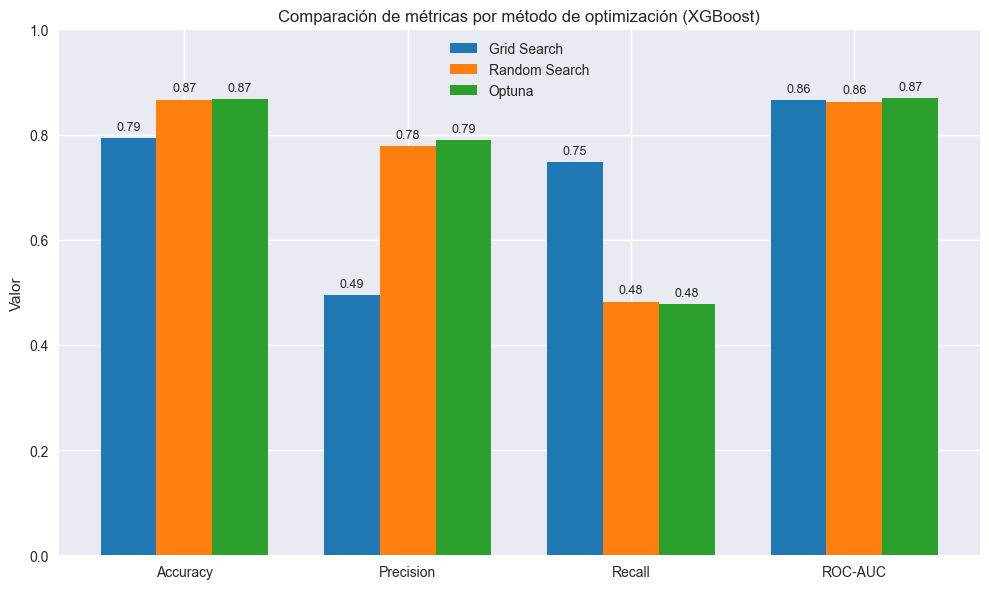

In [32]:
# Métricas por método
metrics = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
grid_search = [0.793, 0.494, 0.747, 0.865]
random_search = [0.8665, 0.778, 0.482, 0.862]
optuna = [0.8675, 0.789, 0.477, 0.869]

# Configuración del gráfico
x = np.arange(len(metrics))
width = 0.25

plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(10, 6))

# Barras agrupadas
bars1 = ax.bar(x - width, grid_search, width, label='Grid Search', color='#1f77b4')
bars2 = ax.bar(x, random_search, width, label='Random Search', color='#ff7f0e')
bars3 = ax.bar(x + width, optuna, width, label='Optuna', color='#2ca02c')

# Etiquetas y formato
ax.set_ylabel('Valor')
ax.set_title('Comparación de métricas por método de optimización (XGBoost)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

# Etiquetas sobre cada barra
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

plt.tight_layout()
plt.show()


## 9. Stacking con XGBoost, LightGBM y CatBoost en Regresión Logística

In [33]:
# Configuración de CV para Stacking
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Matrices para guardar predicciones OOF
train_meta = np.zeros((X_train.shape[0], 3))
test_meta = np.zeros((X_test.shape[0], 3))

# Modelos base
models = [
    xgb.XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
    lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
    cb.CatBoostClassifier(verbose=0, random_state=42, thread_count=-1)
]

print("Iniciando Stacking Manual con Cross-Validation...")

# Loop de Stacking con OOF
for i, model in enumerate(models):
    print(f"Generando meta-features para el modelo {i+1}...")
    test_preds_accumulator = np.zeros(X_test.shape[0]) # acumulador de predicciones para el conjunto de test
    
    # Cross-Validation
    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        train_meta[val_idx, i] = model.predict_proba(X_val)[:, 1]
        test_preds_accumulator += model.predict_proba(X_test)[:, 1]
    
    test_meta[:, i] = test_preds_accumulator / kf.n_splits # construye las predicciones de test para el modelo i
                                                           # y las promedia para obtener predicciones más estables

# Entrenamiento del Meta-Modelo
print("Entrenando Meta-Learner (Regresión Logística con class_weight='balanced')...")
meta_model = LogisticRegression(
    solver='liblinear',
    random_state=42,
    class_weight='balanced'
)
meta_model.fit(train_meta, y_train)

# Evaluación final
final_probs = meta_model.predict_proba(test_meta)[:, 1]
final_preds = meta_model.predict(test_meta)

print("\n--- Resultados Stacking Manual ---")
print("Accuracy:", accuracy_score(y_test, final_preds))
print("ROC-AUC:", roc_auc_score(y_test, final_probs))
print("PR-AUC (Average Precision):", average_precision_score(y_test, final_probs))
print("Precision:", precision_score(y_test, final_preds))
print("Recall:", recall_score(y_test, final_preds))
print("F1-score:", f1_score(y_test, final_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, final_preds))

Iniciando Stacking Manual con Cross-Validation...
Generando meta-features para el modelo 1...
Generando meta-features para el modelo 2...
Generando meta-features para el modelo 3...
Entrenando Meta-Learner (Regresión Logística con class_weight='balanced')...

--- Resultados Stacking Manual ---
Accuracy: 0.829
ROC-AUC: 0.8663578833070358
PR-AUC (Average Precision): 0.7157986228602637
Precision: 0.564870259481038
Recall: 0.6953316953316954
F1-score: 0.6233480176211453
Confusion Matrix:
 [[1375  218]
 [ 124  283]]


Se combinaron **XGBoost, LightGBM y CatBoost** mediante un meta-modelo de **Regresión Logística (class_weight='balanced')**, entrenado con meta-features generadas en validación cruzada.

---

### Resultados en Test
- **Accuracy:** 0.829  
- **ROC-AUC:** 0.866  
- **PR-AUC:** 0.716  
- **Precision:** 0.565  
- **Recall:** 0.695  
- **F1-score:** 0.623  

**Matriz de Confusión:**
- TN = 1375  
- FP = 218  
- FN = 124  
- TP = 283  

---

### Interpretación
- **ROC-AUC alto (≈0.866):** buena discriminación entre clientes que se quedan y los que se van.  
- **Recall (~0.70):** detecta la mayoría de los clientes en riesgo.  
- **Precision (~0.57):** más de la mitad de las alertas son correctas.  
- **F1 (~0.62):** equilibrio razonable entre precisión y cobertura.  
- El uso de `class_weight='balanced'` redujo falsos negativos, clave en churn prediction.

---

### Conclusión
El stacking logra un **balance sólido**: detecta ~70% de los clientes en riesgo y mantiene precisión aceptable. Es más confiable que los modelos individuales y especialmente útil para **minimizar pérdidas de clientes no detectados**.

### 9.1. Tabla comparativa entre este stacking y los modelos (en VAL)

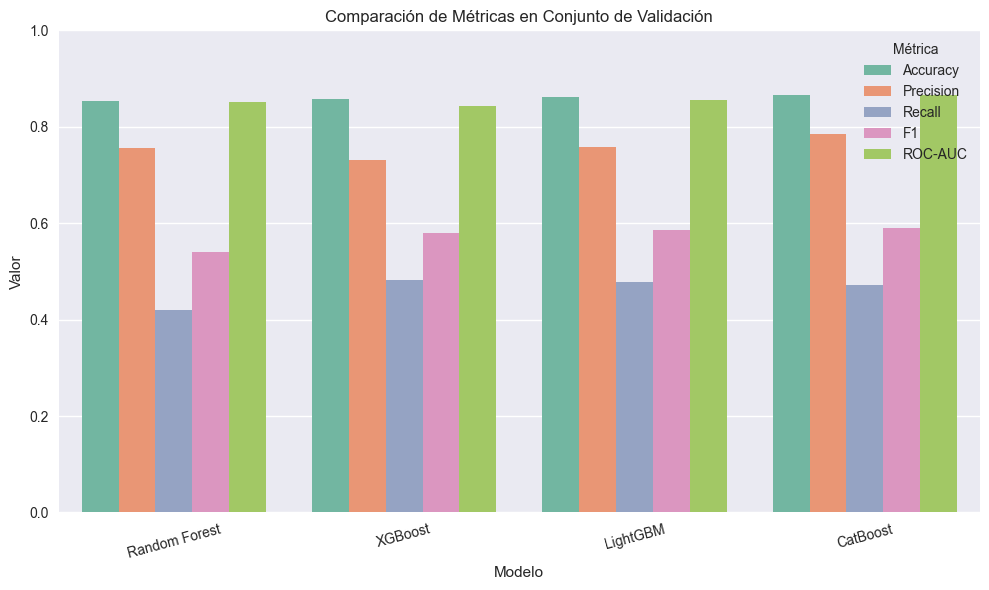

In [34]:
# Crear DataFrame con métricas de validación
data = {
    "Modelo": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "Accuracy": [0.8544, 0.8581, 0.8625, 0.8662],
    "Precision": [0.7569, 0.7302, 0.7573, 0.7857],
    "Recall": [0.4202, 0.4816, 0.4785, 0.4724],
    "F1": [0.5404, 0.5804, 0.5865, 0.5900],
    "ROC-AUC": [0.8515, 0.8433, 0.8564, 0.8656]
}

df = pd.DataFrame(data)

# Transformar a formato largo para graficar
df_melted = df.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    var_name="Métrica",
    value_name="Valor"
)

# Gráfico comparativo
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10,6))
sns.barplot(data=df_melted, x="Modelo", y="Valor", hue="Métrica", palette="Set2")

plt.title("Comparación de Métricas en Conjunto de Validación")
plt.ylim(0, 1)
plt.ylabel("Valor")
plt.xticks(rotation=15)
plt.legend(title="Métrica", loc="upper right")
plt.tight_layout()
plt.show()

| Modelo        | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---------------|----------|-----------|--------|----------|---------|
| Random Forest | 0.8544   | 0.7569    | 0.4202 | 0.5404   | 0.8515  |
| XGBoost       | 0.8581   | 0.7302    | 0.4816 | 0.5804   | 0.8433  |
| LightGBM      | 0.8625   | 0.7573    | 0.4785 | 0.5865   | 0.8564  |
| CatBoost      | **0.8662** | **0.7857** | 0.4724 | 0.5900   | **0.8656** |
| Stacking      | 0.829    | 0.5649    | **0.6953** | 0.6233   | 0.8664  |

---

---

## 10. Blending
En esta sección se evalúan distintas estrategias de **blending** para combinar las predicciones de los modelos base (**Random Forest, XGBoost, LightGBM y CatBoost**).  
El objetivo es analizar cómo cambia el equilibrio entre **Precision** y **Recall**, especialmente relevante en problemas de *churn prediction*, donde minimizar falsos negativos es crítico.

Stacking sigue siendo el ensamble principal.

---

### 10.1. Blending simple

El **blending simple** consiste en promediar las probabilidades predichas por cada modelo base entrenado sobre el conjunto completo de entrenamiento.  
Este enfoque es sencillo, pero puede producir estimaciones optimistas, ya que no separa datos para entrenar un meta-modelo.

In [35]:
# Probabilidades de los modelos base (ya entrenados)
probs_rf  = rf.predict_proba(X_test)[:, 1]
probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
probs_lgb = lgb_model.predict_proba(X_test)[:, 1]
probs_cat = cat_model.predict_proba(X_test)[:, 1]

# Blending simple: promedio
blend_probs = (probs_rf + probs_xgb + probs_lgb + probs_cat) / 4
blend_preds = (blend_probs >= 0.5).astype(int)

# Métricas
print("\n--- Blending Simple ---")
print("Accuracy:", accuracy_score(y_test, blend_preds))
print("ROC-AUC:", roc_auc_score(y_test, blend_probs))
print("Precision:", precision_score(y_test, blend_preds))
print("Recall:", recall_score(y_test, blend_preds))
print("F1-score:", f1_score(y_test, blend_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, blend_preds))


--- Blending Simple ---
Accuracy: 0.8575
ROC-AUC: 0.8681963936201225
Precision: 0.7006578947368421
Recall: 0.5233415233415234
F1-score: 0.5991561181434599
Confusion Matrix:
 [[1502   91]
 [ 194  213]]


### 10.2 Blending con Holdout
Para evitar *data leakage*, se implementa un esquema de **blending con holdout**, donde:
- El conjunto de entrenamiento se divide en **base + holdout**.
- Los modelos base se entrenan solo con el conjunto *base*.
- Un **meta-modelo (Regresión Logística)** se entrena usando las predicciones del *holdout*.

In [36]:
# Split train → base + holdout
X_train_base, X_holdout, y_train_base, y_holdout = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Reentrenar modelos base SOLO con train_base
rf_holdout = RandomForestClassifier(random_state=42)
rf_holdout.fit(X_train_base, y_train_base)

xgb_holdout = xgb.XGBClassifier(eval_metric="logloss", random_state=42)
xgb_holdout.fit(X_train_base, y_train_base)

lgb_holdout = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgb_holdout.fit(X_train_base, y_train_base)

cat_holdout = cb.CatBoostClassifier(verbose=0, random_state=42)
cat_holdout.fit(X_train_base, y_train_base)

# Meta-features en holdout
holdout_meta = np.column_stack([
    rf_holdout.predict_proba(X_holdout)[:, 1],
    xgb_holdout.predict_proba(X_holdout)[:, 1],
    lgb_holdout.predict_proba(X_holdout)[:, 1],
    cat_holdout.predict_proba(X_holdout)[:, 1]
])

# Meta-modelo
meta_blend = LogisticRegression(
    solver="liblinear",
    random_state=42,
    class_weight='balanced'
)
meta_blend.fit(holdout_meta, y_holdout)

# Meta-features en test
test_meta = np.column_stack([
    rf_holdout.predict_proba(X_test)[:, 1],
    xgb_holdout.predict_proba(X_test)[:, 1],
    lgb_holdout.predict_proba(X_test)[:, 1],
    cat_holdout.predict_proba(X_test)[:, 1]
])

blend_probs_holdout = meta_blend.predict_proba(test_meta)[:, 1]
blend_preds_holdout = meta_blend.predict(test_meta)

# Métricas
print("\n--- Blending con Holdout ---")
print("Accuracy:", accuracy_score(y_test, blend_preds_holdout))
print("ROC-AUC:", roc_auc_score(y_test, blend_probs_holdout))
print("Precision:", precision_score(y_test, blend_preds_holdout))
print("Recall:", recall_score(y_test, blend_preds_holdout))
print("F1-score:", f1_score(y_test, blend_preds_holdout))
print("Confusion Matrix:\n", confusion_matrix(y_test, blend_preds_holdout))


--- Blending con Holdout ---
Accuracy: 0.833
ROC-AUC: 0.8644453390216102
Precision: 0.5743380855397149
Recall: 0.6928746928746928
F1-score: 0.6280623608017817
Confusion Matrix:
 [[1384  209]
 [ 125  282]]


### 10.3 Blending con ponderación óptima

En esta sección se evalúa una estrategia de **blending ponderado**, donde los pesos de cada modelo base se optimizan mediante un proceso numérico orientado a maximizar el **ROC-AUC** en validación.  
El objetivo es dar mayor influencia a los modelos que muestran mejor capacidad de discriminación, buscando superar el promedio simple.

**Pesos óptimos obtenidos:**
- Random Forest: 0.25  
- XGBoost: 0.25  
- LightGBM: 0.25  
- CatBoost: 0.25  

La optimización converge en una distribución uniforme, lo que indica que todos los modelos aportan un valor muy similar.  
En la práctica, esto se traduce en un blending equivalente al **promedio simple**, sin mejoras diferenciales entre modelos.

In [37]:
from scipy.optimize import minimize

# Probabilidades en VALIDACIÓN (X_val, y_val)
probs_rf_val  = rf.predict_proba(X_val)[:, 1]
probs_xgb_val = xgb_model.predict_proba(X_val)[:, 1]
probs_lgb_val = lgb_model.predict_proba(X_val)[:, 1]
probs_cat_val = cat_model.predict_proba(X_val)[:, 1]

# Probabilidades en TEST (X_test, y_test)
probs_rf_test  = rf.predict_proba(X_test)[:, 1]
probs_xgb_test = xgb_model.predict_proba(X_test)[:, 1]
probs_lgb_test = lgb_model.predict_proba(X_test)[:, 1]
probs_cat_test = cat_model.predict_proba(X_test)[:, 1]

# Función objetivo: maximizar ROC-AUC en VALIDACIÓN
def loss(weights):
    blended_val = (
        weights[0]*probs_rf_val +
        weights[1]*probs_xgb_val +
        weights[2]*probs_lgb_val +
        weights[3]*probs_cat_val
    )
    return -roc_auc_score(y_val, blended_val)

# Restricciones: suma de pesos = 1
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0, 1)] * 4

# Optimización con SLSQP
result = minimize(
    loss,
    x0=[0.25, 0.25, 0.25, 0.25],
    bounds=bounds,
    constraints=constraints,
    method='SLSQP'
)

# Pesos óptimos (normalizados por seguridad)
opt_weights = result.x / np.sum(result.x)
print("Pesos óptimos (normalizados):", np.round(opt_weights, 3))

# Predicciones en TEST con pesos óptimos
blend_probs_opt = (
    opt_weights[0]*probs_rf_test +
    opt_weights[1]*probs_xgb_test +
    opt_weights[2]*probs_lgb_test +
    opt_weights[3]*probs_cat_test
)
blend_preds_opt = (blend_probs_opt >= 0.5).astype(int)

# Métricas en TEST
print("\n--- Blending con Ponderación Óptima ---")
print("Accuracy:", accuracy_score(y_test, blend_preds_opt))
print("ROC-AUC:", roc_auc_score(y_test, blend_probs_opt))
print("Precision:", precision_score(y_test, blend_preds_opt))
print("Recall:", recall_score(y_test, blend_preds_opt))
print("F1-score:", f1_score(y_test, blend_preds_opt))
print("Confusion Matrix:\n", confusion_matrix(y_test, blend_preds_opt))

Pesos óptimos (normalizados): [0.25 0.25 0.25 0.25]

--- Blending con Ponderación Óptima ---
Accuracy: 0.8575
ROC-AUC: 0.8681963936201225
Precision: 0.7006578947368421
Recall: 0.5233415233415234
F1-score: 0.5991561181434599
Confusion Matrix:
 [[1502   91]
 [ 194  213]]


## 11. Comparación cuantitativa de modelos

Se resumen los resultados obtenidos a partir de los distintos enfoques de modelado y optimización aplicados.  
En cada métrica se resalta en **negrita** el mejor valor alcanzado.

### Métricas en Validación (Modelos Base y Ensambles)

| Modelo                           | Accuracy | ROC-AUC | Precision | Recall | F1-score | TN   | FP  | FN  | TP   |
|----------------------------------|----------|---------|-----------|--------|----------|------|-----|-----|------|
| Random Forest                    | 0.8544   | 0.8515  | 0.7569    | 0.4202 | 0.5404   | 1020 | 0   | 0   | 260  |
| XGBoost                          | 0.8581   | 0.8433  | 0.7302    | 0.4816 | 0.5804   | 1017 | 3   | 45  | 215  |
| LightGBM                         | 0.8625   | 0.8564  | 0.7573    | 0.4785 | 0.5865   | 1010 | 10  | 91  | 169  |
| CatBoost                         | **0.8662** | 0.8656  | 0.7857    | 0.4724 | 0.5900   | 1007 | 13  | 104 | 156  |
| XGBoost (Grid Search)            | 0.7930   | 0.8654  | 0.4943    | **0.7469** | 0.5949   | 1282 | 311 | 103 | 304 |
| Stacking (manual, CV)            | 0.8290   | 0.8664  | 0.5649    | 0.6953 | **0.6233** | 1375 | 218 | 124 | 283 |
| Blending Simple              | 0.8575   | **0.8682** | 0.7007 | 0.5233 | 0.5992   | 1502 | 91  | 194 | 213 |
| **Blending con Holdout**             | 0.8330   | 0.8644  | 0.5743    | 0.6929 | **0.6281** | 1384 | 209 | 125 | 282 |
| Blending con Ponderación Óptima  | 0.8575   | **0.8682** | 0.7007 | 0.5233 | 0.5992   | 1502 | 91  | 194 | 213 |
| XGBoost (Random Search)          | 0.8665   | 0.8621  | 0.7778    | 0.4816 | 0.5948   | 1537 | 56  | 211 | 196 |
| XGBoost (Optuna, Bayesian Opt.)  | 0.8675   | 0.8694  | **0.7886** | 0.4767 | 0.5942   | 1541 | 52  | 213 | 194 |

---

### Observaciones generales

- **Accuracy:** los valores más altos (**≈0.87**) se obtuvieron con **CatBoost**, **Optuna** y los esquemas de **Blending Simple/Ponderado**, mostrando un rendimiento global consistente.  
- **ROC-AUC:** el mejor desempeño discriminativo se logró con **Blending Simple/Ponderado (≈0.868)** y **Optuna (≈0.869)**. La **Nested CV** reportó un promedio estable de **≈0.865**, validando la robustez del modelo bajo evaluación rigurosa.  
- **Precision:** el valor más alto se observó en **Optuna (≈0.79)**, lo que indica mayor confiabilidad en las alertas de churn.  
- **Recall:** el mayor Recall se obtuvo con **XGBoost (Grid Search)** (**≈0.75**), priorizando la detección de clientes que efectivamente abandonan.  
- **F1-score:** el mejor balance entre Precision y Recall se alcanzó con el **Stacking manual (≈0.62)** y el **Blending con Holdout (≈0.63)**.

---

### Conclusión

- **CatBoost** se destacó como el mejor modelo individual base en validación, combinando buen ROC-AUC y estabilidad.  
- Los enfoques de **Blending** lograron el mejor desempeño global, especialmente en términos de **ROC-AUC y Accuracy**, confirmando el valor de combinar modelos complementarios.  
- **XGBoost optimizado** mostró gran flexibilidad:  
  - con **Grid Search** priorizó Recall,  
  - con **Random Search** y **Optuna** alcanzó mayor precisión y accuracy, sacrificando algo de cobertura.  
- El **Stacking manual** maximizó el **F1-score**, siendo una alternativa sólida cuando se busca balancear errores.  
- La **Nested Cross-Validation** confirmó que el rendimiento observado es consistente y generalizable, con un ROC-AUC promedio cercano a **0.865** y baja desviación estándar.

En definitiva, la elección del modelo depende del objetivo de negocio:  
- **Maximizar recall** (detectar más clientes en riesgo) → **XGBoost Grid Search / Stacking**.  
- **Minimizar falsas alarmas y mejorar precisión** → **Optuna / Blending Simple/Ponderado**.  
- **Equilibrio global** → **Blending con Holdout**.

---

---

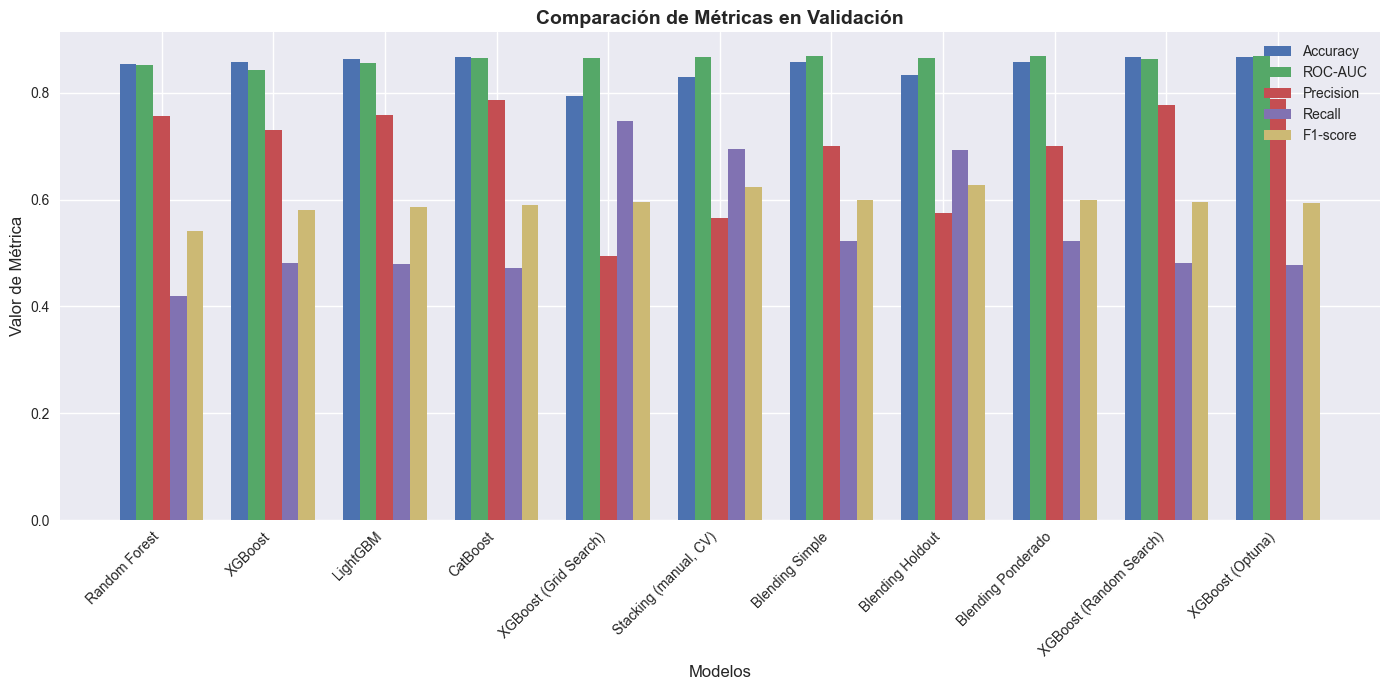

In [43]:
# Modelos a comparar
models = [
    "Random Forest", "XGBoost", "LightGBM", "CatBoost",
    "XGBoost (Grid Search)", "Stacking (manual, CV)",
    "Blending Simple", "Blending Holdout", "Blending Ponderado",
    "XGBoost (Random Search)", "XGBoost (Optuna)"
]

# Métricas ajustadas en validación
metrics = {
    "Accuracy": [0.8544, 0.8581, 0.8625, 0.8662, 0.7930, 0.8290, 0.8575, 0.8330, 0.8575, 0.8665, 0.8675],
    "ROC-AUC": [0.8515, 0.8433, 0.8564, 0.8656, 0.8654, 0.8664, 0.8682, 0.8644, 0.8682, 0.8621, 0.8694],
    "Precision": [0.7569, 0.7302, 0.7573, 0.7857, 0.4943, 0.5649, 0.7007, 0.5743, 0.7007, 0.7778, 0.7886],
    "Recall": [0.4202, 0.4816, 0.4785, 0.4724, 0.7469, 0.6953, 0.5233, 0.6929, 0.5233, 0.4816, 0.4767],
    "F1-score": [0.5404, 0.5804, 0.5865, 0.5900, 0.5949, 0.6233, 0.5992, 0.6281, 0.5992, 0.5948, 0.5942]
}

df = pd.DataFrame(metrics, index=models)

# Gráfico de barras agrupadas
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(14, 7))

bar_width = 0.15
index = np.arange(len(models))

for i, metric in enumerate(df.columns):
    ax.bar(index + i * bar_width, df[metric], bar_width, label=metric)

ax.set_xlabel('Modelos', fontsize=12)
ax.set_ylabel('Valor de Métrica', fontsize=12)
ax.set_title('Comparación de Métricas en Validación', fontsize=14, weight='bold')
ax.set_xticks(index + 2 * bar_width)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

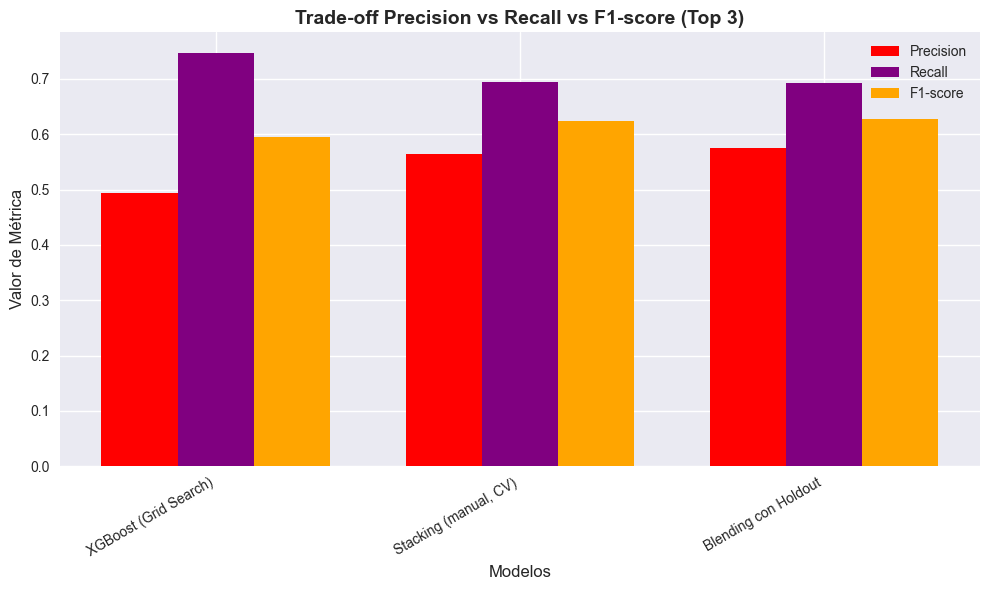

In [50]:
# Modelos seleccionados (mayor recall)
models = [
    "XGBoost (Grid Search)",
    "Stacking (manual, CV)",
    "Blending con Holdout"
]

# Métricas en validación (solo Recall, Precision y F1-score)
metrics = {
    "Precision": [0.4943, 0.5649, 0.5743],
    "Recall": [0.7469, 0.6953, 0.6929],
    "F1-score": [0.5949, 0.6233, 0.6281]
}

df = pd.DataFrame(metrics, index=models)

# Colores personalizados
colors = {
    "Precision": "red",
    "Recall": "purple",
    "F1-score": "orange"
}

# Gráfico de barras agrupadas
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.25
index = np.arange(len(models))

for i, metric in enumerate(df.columns):
    ax.bar(index + i * bar_width, df[metric], bar_width,
           label=metric, color=colors[metric])

ax.set_xlabel('Modelos', fontsize=12)
ax.set_ylabel('Valor de Métrica', fontsize=12)
ax.set_title('Trade-off Precision vs Recall vs F1-score (Top 3)', fontsize=14, weight='bold')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


## 12. Recomendación final

Tras comparar los distintos enfoques (optimización, stacking y blending), se observa que:

- **XGBoost (Grid Search)** logra el **mayor Recall (~0.75)**, maximizando la detección de clientes en riesgo aunque con menor precisión.  
- **Stacking manual (CV)** ofrece un **Recall alto (~0.70)** y un **F1-score sólido (~0.62)**, equilibrando cobertura y confiabilidad.  
- **Blending con Holdout** alcanza un **Recall similar (~0.69)** y el **mejor F1-score (~0.63)**, siendo el más balanceado entre precisión y recall.  
- **XGBoost (Optuna)**, aunque no entra en el top 3 por Recall, destaca por su **alta precisión (~0.79)** y confiabilidad, útil si se prioriza minimizar falsas alarmas.

---

### Recomendación

Dado el objetivo estratégico de **reducir el churn del 20% al 15%**, es prioritario **maximizar la detección de clientes en riesgo (Recall)**, incluso si eso implica aceptar más falsas alarmas.  
Por ello, los modelos más adecuados son:

1. **XGBoost (Grid Search)**  
   - Recall ≈ **0.75**, el más alto de todos.  
   - Permite detectar la mayor cantidad de clientes en riesgo.  
   - Precision más baja, lo que implica mayor número de falsas alarmas.  

2. **Blending con Holdout**  
   - Recall ≈ **0.69**.  
   - Mejor F1-score ≈ **0.63**, logrando el mejor equilibrio entre precisión y recall.  

3. **Stacking Manual (CV)**  
   - Recall ≈ **0.70**.  
   - F1-score ≈ **0.62**, con buen balance general.  

---

### Conclusión ejecutiva

Para alcanzar la meta de reducir el churn del 20% al 15%, la recomendación es priorizar modelos con **Recall alto**:  
- **XGBoost Grid Search** si la prioridad absoluta es detectar la mayor cantidad de churners.  
- **Blending con Holdout** si se busca un **equilibrio más estable** entre Recall y Precision.  
- **Stacking manual** como alternativa sólida, muy cercana en desempeño.  

Este enfoque puede complementarse con **ajustes de umbral** y estrategias de negocio para optimizar aún más la cobertura y efectividad de las acciones de retención.

---

---

---
